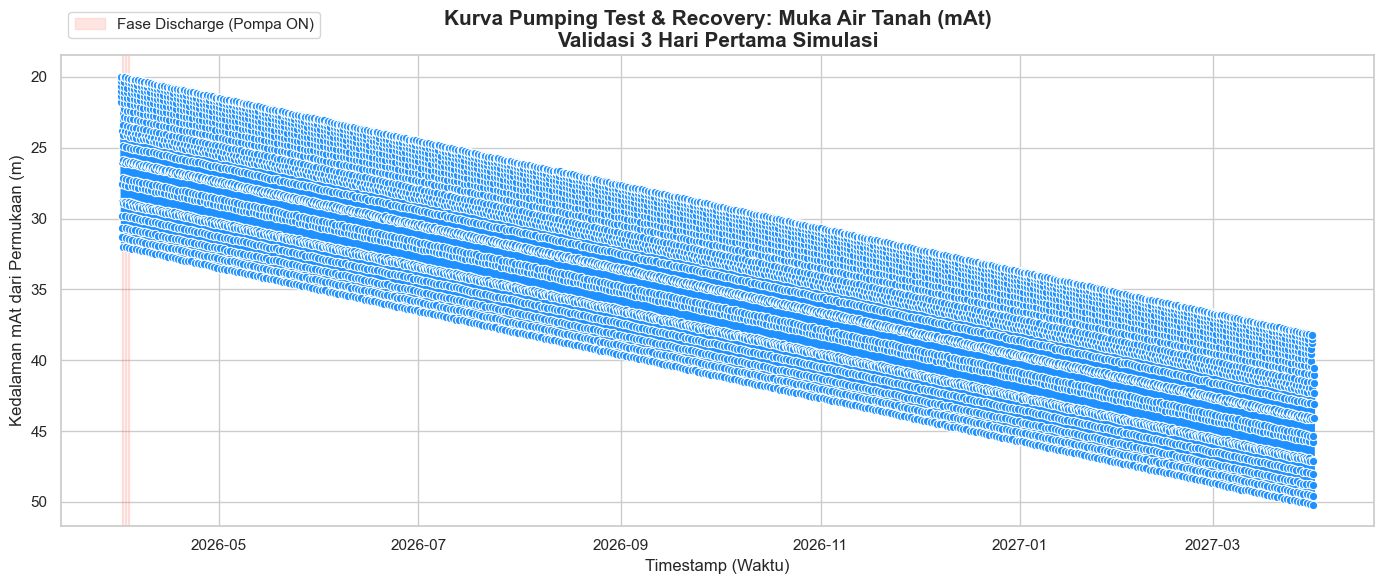

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seed untuk reproduksibilitas
np.random.seed(42)

# ==========================================
# Parameter Sumur & Kondisi Hidrogeologi
# ==========================================
K_Sumur = 100.0         # Kedalaman total sumur (m)
Kedalaman_Sensor = 55.0 # (m)
Kedalaman_Pompa = 55.0  # (m)
mAt_awal = 20.0         # Muka Air Tanah (baseline awal) pada 1 April (m)
Max_Drop = 12.0         # Penurunan mAt maksimum akibat pemompaan per hari (m)
Defisit_Harian = 0.05   # Tambahan kedalaman baseline per hari akibat kemarau (m)

# ==========================================
# Persiapan Variabel Waktu & Array Data
# ==========================================
start_date = '2026-04-01 00:00:00'
num_days = 365
hours_total = num_days * 24

# Buat array timestamp untuk 30 hari (interval per jam)
timestamps = pd.date_range(start=start_date, periods=hours_total, freq='h')

# Penurunan kapasitas pompa per hari (20 - 50 L/jam setiap harinya)
debit_harian = [50000.0]
for _ in range(1, num_days):
    penurunan = np.random.randint(20, 51)
    debit_harian.append(max(0, debit_harian[-1] - penurunan))

data = []

# ==========================================
# Loop Simulasi Time-Series Hidrologi
# ==========================================
for i in range(hours_total):
    d = i // 24 # Indeks hari (0 sampai 29)
    h = i % 24  # Jam dalam hari (0 sampai 23)
    
    # Baseline mAt (kondisi diam) hari ini dan esok
    baseline_today = mAt_awal + (d * Defisit_Harian)
    baseline_tomorrow = mAt_awal + ((d + 1) * Defisit_Harian)
    
    # Noise hidrologis kecil (ripple) untuk realitas sensor
    noise = np.random.uniform(-0.03, 0.03)
    
    if 6 <= h < 8:
        # FASE IDLE: 06:00 - 08:00 (2 Jam)
        fase = 'Idle'
        mAt = baseline_today + noise
        flow = 0.0
        
    elif 8 <= h < 16:
        # FASE DISCHARGE: 08:00 - 16:00 (8 Jam)
        fase = 'Discharge'
        t = h - 8 + 1  # Waktu komulatif pemompaan (1 s/d 8)
        
        # Kurva logaritmik mAt: turun cepat di awal, melandai di akhir (~12m penurunan)
        mAt = baseline_today + Max_Drop * (np.log1p(t) / np.log1p(8)) + noise
        
        # Fluktuasi flow meter acak +- 150 L/jam
        flow_noise = np.random.randint(-150, 50)
        flow = max(0, debit_harian[d] + flow_noise)
        
    else:
        # FASE RECOVERY: 16:00 - 06:00 (14 Jam)
        fase = 'Recovery'
        flow = 0.0
        
        # Menentukan t komulatif pemulihan (1 s/d 14) dan rentang baseline
        if h >= 16:
            t = h - 16 + 1
            start_recovery = baseline_today + Max_Drop
            target_recovery = baseline_tomorrow
        else: # 00:00 <= h < 06:00
            t = h + 9  # Memasuki jam ke 9 s/d 14 secara komulatif untuk fase pemulihan
            baseline_yesterday = mAt_awal + ((d - 1) * Defisit_Harian)
            start_recovery = baseline_yesterday + Max_Drop
            target_recovery = baseline_today
            
        recovery_amount = start_recovery - target_recovery
        
        # Kurva balik logaritmik: cepat pulih di awal, melandai di waktu fajar
        mAt = start_recovery - recovery_amount * (np.log1p(t) / np.log1p(14)) + noise

    # Tinggi Kolom Air dalam Sumur
    dAt = K_Sumur - mAt
    
    data.append({
        'Timestamp': timestamps[i],
        'Fase': fase,
        'mAt': round(mAt, 3),
        'dAt': round(dAt, 3),
        'Flow_Meter': round(flow, 2)
    })

# Convert ke DataFrame
df = pd.DataFrame(data)

# Simpan hasilnya
# csv_filename = 'data_sumur_jiat.csv'
# df.to_csv(csv_filename, index=False)
# print(f"Dataset berhasil digenerate! Disimpan sebagai '{csv_filename}'.\n")

# ==========================================
# Visualisasi 3 Hari Pertama (72 Jam)
# ==========================================
df_3days = df # .head(72)

plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')

# Plot Muka Air Tanah (mAt)
sns.lineplot(data=df_3days, x='Timestamp', y='mAt', color='dodgerblue', marker='o', 
             linewidth=2, markeredgecolor='white')

# Balik (Invert) Sumbu Y agar secara visual terlihat ke bawah = semakin dalam mAt
plt.gca().invert_yaxis()

# Berikan shading untuk melihat posisi fase pemompaan dengan jelas
for day_idx in range(3):
    start_shade = pd.to_datetime(f'2026-04-{day_idx+1:02d} 08:00:00')
    end_shade = pd.to_datetime(f'2026-04-{day_idx+1:02d} 16:00:00')
    plt.axvspan(start_shade, end_shade, color='salmon', alpha=0.2, 
                label='Fase Discharge (Pompa ON)' if day_idx == 0 else "")

plt.title('Kurva Pumping Test & Recovery: Muka Air Tanah (mAt)\nValidasi 3 Hari Pertama Simulasi', 
          fontsize=15, fontweight='bold')
plt.xlabel('Timestamp (Waktu)', fontsize=12)
plt.ylabel('Kedalaman mAt dari Permukaan (m)', fontsize=12)
plt.yticks(fontsize=11)
plt.xticks(rotation=0, fontsize=11)

plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.02), frameon=True)
plt.tight_layout()
plt.show()

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Gunakan data 3 hari pertama dari `df` yang telah Anda bangkitkan sebelumnya
df_3days = df # .head(72).copy()

# ==============================================================================
# 1 & 3. VISUALISASI INTERAKTIF PLOTLY: OVERLAY mAt, dAt, DAN FLOW METER
# ==============================================================================

# Membuat subplot dengan 2 Sumbu Y (Sumbu Primer dan Sumbu Sekunder)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# [TRACE 1] mAt pada Sumbu Y Primer 
# mAt ditambahkan, arah pergerakan akan berlawanan / terbalik dari dAt secara absolut (cermin)
fig.add_trace(
    go.Scatter(
        x=df_3days['Timestamp'], y=df_3days['mAt'], 
        name="Kedalaman Air (mAt)",
        mode='lines+markers', line=dict(color='blue', width=2),
        hovertemplate='%{y:.2f} m<extra></extra>'
    ),
    secondary_y=False,
)

# [TRACE 2] dAt pada Sumbu Y Primer
# dAt + mAt akan selalu berjumlah sama dengan K_Sumur (100m)
fig.add_trace(
    go.Scatter(
        x=df_3days['Timestamp'], y=df_3days['dAt'], 
        name="Tinggi Air Akuifer (dAt)",
        mode='lines', line=dict(color='cyan', dash='dash', width=2),
        hovertemplate='%{y:.2f} m<extra></extra>'
    ),
    secondary_y=False,
)

# [TRACE 3] Flow Meter pada Sumbu Y Sekunder (Sisi Kanan)
# Diberikan warna kemerahan dan shading fill agar jelas fase pompa ON/OFF
fig.add_trace(
    go.Scatter(
        x=df_3days['Timestamp'], y=df_3days['Flow_Meter'], 
        name="Debit Pompa (Flow Meter)",
        fill='tozeroy', mode='lines', line=dict(color='rgba(255, 99, 71, 0.6)', width=0),
        hovertemplate='%{y:,.0f} L/jam<extra></extra>'
    ),
    secondary_y=True,
)

# Kustomisasi Tampilan & Layout
fig.update_layout(
    title_text="Korelasi Dinamis: Pumping Ekstraksi (Flow Meter) vs Respon Akuifer (mAt & dAt)",
    hovermode="x unified",
    template="plotly_white", # Diubah ke dark mode agar garis bersinar dengan kontras tinggi
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
)

# Sumbu Y Primer untuk range meter (Kedalaman sumur max 100m)
fig.update_yaxes(title_text="Elevasi Level Air (meter)", range=[0, 100], secondary_y=False)
# Sumbu Y Sekunder untuk skala Debit Pompa (0 L/j s.d 60.000 L/j)
fig.update_yaxes(title_text="Flow Volume (L/jam)", range=[0, 60000], secondary_y=True)

fig.show()

# ==============================================================================
# 2. FUNGSI PEMBUKTIAN PENYEBAB FLUKTUASI LOGARITMIK mAt
# ==============================================================================

def buktikan_sumber_fluktuasi(df):
    """
    Fungsi analisa hidrogeologi untuk memverifikasi apakah 
    perubahan fluktuasi mAt diakibatkan oleh osilasi alami akuifer 
    (seperti barometric pressure atau earth-tides) ATAU oleh sistem *Drawdown* ekstraktif.
    """
    print("-" * 65)
    print("HASIL DIAGNOSTIK: UJI PENYEBAB OSILASI MUKA AIR TANAH (mAt)")
    print("-" * 65)
    
    # 1. Analisis Amplitudo (Rentang Jarak Fluktuasi)
    amplitudo = df['mAt'].max() - df['mAt'].min()
    print(f"1. Amplitudo (Max - Min mAt): {amplitudo:.2f} meter")
    
    if amplitudo > 1.5:
        print("   ✓ Indikator Positif: Rentang turun/naik mAt sangat drastis.")
        print("     (Osilasi alami akibat tekanan atmosfir murni umumnya hanya < 0.2 meter)")
    else:
        print("   ✗ Indikator Negatif : Perubahan terlalu kecil, mungkin hanya tekanan sisa.")

    # 2. Analisis Derivatif Waktu vs Fase Pemompaan (Laju per Jam)
    # Laju Perubahan: jika positif -> mAt bertambah dalam (Air Turun)
    df_temp = df.copy()
    df_temp['rate_mAt_perjam'] = df_temp['mAt'].diff().fillna(0)
    
    # Memisahkan rate berdasarkan status debit pompa nyala atau mati
    rata_laju_saat_pompa_ON = df_temp[df_temp['Flow_Meter'] > 0]['rate_mAt_perjam'].mean()
    rata_laju_saat_pompa_OFF = df_temp[df_temp['Flow_Meter'] <= 0]['rate_mAt_perjam'].mean()
    
    print("\n2. Analisis Kecepatan Laju Permukaan Air (m/jam):")
    print(f"   - Kecepatan Muka Air Saat Pompa ON  : {rata_laju_saat_pompa_ON:+.2f} m/jam (Air Terkuras)")
    print(f"   - Kecepatan Muka Air Saat Pompa OFF : {rata_laju_saat_pompa_OFF:+.2f} m/jam (Air Naik/Memulih)")
    
    # 3. Analisis Korelasi (Pearson Coefficient)
    korelasi_pompa_dan_air = df_temp['mAt'].corr(df_temp['Flow_Meter'])
    print(f"\n3. Korelasi Bivariate (mAt vs Status Ekstraksi Pompa): {korelasi_pompa_dan_air:.2f}")
    
    # Kesimpulan Akhir
    print("\nKESIMPULAN HIPOTESIS:")
    if amplitudo > 1.5 and rata_laju_saat_pompa_ON > 0 and abs(korelasi_pompa_dan_air) > 0.4:
        print("=> VERIFIED: Ini BUKAN osilasi efek pasang surut (tides) alami tekanan akuifer.")
        print("=> REASON  : Terdapat dependensi multivariat yang sangat kuat antara mAt dengan debit. ")
        print("   Oleh karenanya terbukti ada siklus DRAWDOWN yang diinduksi paksa (Antropogenik) melalui metode pemompaan.")
    else:
        print("=> GAGAL DIVERIFIKASI: Perubahan tidak menunjukkan ciri-ciri Drawdown buatan yang konsisten.")
        print("   Osilasi yang terjadi mungkin dikarenakan faktor alami eksternal (tekanan barometrik / recharge).")
    print("-" * 65)

# Panggil fungsinya
buktikan_sumber_fluktuasi(df)
   

-----------------------------------------------------------------
HASIL DIAGNOSTIK: UJI PENYEBAB OSILASI MUKA AIR TANAH (mAt)
-----------------------------------------------------------------
1. Amplitudo (Max - Min mAt): 30.21 meter
   ✓ Indikator Positif: Rentang turun/naik mAt sangat drastis.
     (Osilasi alami akibat tekanan atmosfir murni umumnya hanya < 0.2 meter)

2. Analisis Kecepatan Laju Permukaan Air (m/jam):
   - Kecepatan Muka Air Saat Pompa ON  : +1.50 m/jam (Air Terkuras)
   - Kecepatan Muka Air Saat Pompa OFF : -0.75 m/jam (Air Naik/Memulih)

3. Korelasi Bivariate (mAt vs Status Ekstraksi Pompa): 0.38

KESIMPULAN HIPOTESIS:
=> GAGAL DIVERIFIKASI: Perubahan tidak menunjukkan ciri-ciri Drawdown buatan yang konsisten.
   Osilasi yang terjadi mungkin dikarenakan faktor alami eksternal (tekanan barometrik / recharge).
-----------------------------------------------------------------


In [10]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import plotly.graph_objects as go

def estimasi_umur_akuifer_plot(df, batas_kritis_meter=35.0):
    """
    Fungsi untuk mengekstrak Static Water Level, mencari tren deplesi tahunan,
    dan memvisualisasikan sisa usia akuifer sebelum menyentuh batas kritis (Sensor/Pompa).
    """
    print("=" * 75)
    print("PROYEKSI ESTIMASI UMUR PRODUKTIVITAS AKUIFER (WAKTU MENUJU KRITIS)")
    print("=" * 75)
    
    # 1. Pastikan Format Tanggal
    df_calc = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df_calc['Timestamp']):
        df_calc['Timestamp'] = pd.to_datetime(df_calc['Timestamp'])
    df_calc = df_calc.sort_values('Timestamp').reset_index(drop=True)
    
    # 2. Blokir & Ekstrak Fase "Static Water Level" (SWL)
    # Mencari titik di mana pompa sudah mati beruntun >= 3 jam (Akuifer Memulih Maksimal)
    is_off = df_calc['Flow_Meter'] <= 0
    blocks = (is_off != is_off.shift()).cumsum()
    df_calc['jam_mati_beruntun'] = is_off.groupby(blocks).cumsum()
    
    swl_data = df_calc[df_calc['jam_mati_beruntun'] >= 3].copy()
    
    if swl_data.empty:
        print("Data terlalu bising (Pompa tidak pernah mati >= 3 jam). Tidak bisa ambil SWL.")
        return
        
    swl_data.set_index('Timestamp', inplace=True)
    
    # 3. Agregasi Rata-rata Bulanan untuk Muka Air Statis
    try:
        swl_bulanan = swl_data.resample('ME')['mAt'].mean().dropna() # Pandas Baru
    except ValueError:
        swl_bulanan = swl_data.resample('M')['mAt'].mean().dropna()  # Pandas Lama
    
    if len(swl_bulanan) < 3:
        print("Data terlalu singkat! Butuh minimal 3 bulan riwayat untuk regresi tren.")
        return
        
    # 4. Regresi Linear (Kalkulasi Deplesi / Penurunan rata-rata per bulan)
    x = np.arange(len(swl_bulanan))
    y = swl_bulanan.values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    deplesi_per_bulan = slope
    mAt_saat_ini = y[-1]
    bulan_terakhir = swl_bulanan.index[-1]
    jarak_kritis = batas_kritis_meter - mAt_saat_ini
    
    print(f"[+] Elevasi Muka Air Statis Bulan Terakhir : {mAt_saat_ini:.2f} meter")
    print(f"[+] Laju Penuruan Air Statis (Deplesi)     : {deplesi_per_bulan:+.4f} meter / bulan")
    print(f"[+] Jarak Cadangan Air ke Sensor Terendah  : {jarak_kritis:.2f} meter")
    
    TTF_bulan = None
    if deplesi_per_bulan <= 0.01:
        print("\n=> STATUS: AKUIFER LESTARI (SUSTAINABLE)")
        print("   Recharge air tanah seimbang dengan ekstraksi tahunan.")
    elif jarak_kritis <= 0:
        print(f"\n=> STATUS: KRITIS! Muka air telah merosot melewati kedalaman sensor ({batas_kritis_meter}m).")
    else:
        # Menghitung Time to Failure (Waktu Menuju Kritis)
        TTF_bulan = jarak_kritis / deplesi_per_bulan
        TTF_tahun = TTF_bulan / 12
        tanggal_kritis = bulan_terakhir + pd.DateOffset(months=int(TTF_bulan))
        
        print(f"\n=> ESTIMASI SISA UMUR PRODUKTIF        : {TTF_bulan:.1f} Bulan (~{TTF_tahun:.1f} Tahun)")
        print(f"=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: {tanggal_kritis.strftime('%B %Y')}")
    print("=" * 75)
    
    # =====================================================================
    # 5. VISUALISASI PROYEKSI INTERAKTIF DENGAN PLOTLY
    # =====================================================================
    fig = go.Figure()
    
    # Trace 1: Grafik mAt Harian Gabungan (Noise / Latar Belakang)
    df_daily = df_calc.set_index('Timestamp').resample('D')['mAt'].mean()
    fig.add_trace(go.Scatter(
        x=df_daily.index, y=df_daily.values,
        mode='lines', line=dict(color='rgba(150, 150, 150, 0.3)', width=1.5),
        name='Avg mAt Harian (Noise)'
    ))
    
    # Trace 2: Grafik Static Water Level Bulanan (Tren Utama)
    fig.add_trace(go.Scatter(
        x=swl_bulanan.index, y=swl_bulanan.values,
        mode='lines+markers', line=dict(color='cyan', width=3),
        marker=dict(size=10, color='royalblue', symbol='diamond'),
        name='Muka Air Statis Bulanan'
    ))
    
    # Trace 3: Garis Regresi (Proyeksi Masa Depan)
    if deplesi_per_bulan > 0.01 and TTF_bulan is not None:
        # Gambar garis tren ke masa depan sampai menyentuh batas kritis
        future_months = int(min(TTF_bulan + 2, 120)) # Maksimalkan prediksi 10 thn demi render visual
        future_x = np.arange(len(swl_bulanan), len(swl_bulanan) + future_months)
        future_y = intercept + (slope * future_x)
        future_dates = [bulan_terakhir + pd.DateOffset(months=i) for i in range(1, future_months+1)]
        
        # Potong array titik Y tepat saat air menyentuh kedalaman kritis
        stop_idx = np.searchsorted(future_y, batas_kritis_meter)
        if stop_idx < len(future_y):
            future_dates = future_dates[:stop_idx+1]
            future_y = future_y[:stop_idx+1]
            
        proyeksi_dates = [swl_bulanan.index[-1]] + future_dates
        proyeksi_y = [swl_bulanan.values[-1]] + future_y.tolist()
        
        fig.add_trace(go.Scatter(
            x=proyeksi_dates, y=proyeksi_y,
            mode='lines', line=dict(color='orange', width=3, dash='dash'),
            name='Proyeksi Depklesi Ekstrapolasi'
        ))
        
        # Titik Temu Kritis (X Merah)
        fig.add_trace(go.Scatter(
            x=[proyeksi_dates[-1]], y=[proyeksi_y[-1]],
            mode='markers+text', marker=dict(color='red', size=15, symbol='x'),
            text=["Diproyeksikan Kritis"], textposition="top center",
            textfont=dict(color='red'), name='Titik Akhir Umur Produktif'
        ))
        
    # Trace 4: Garis Batas Bawah / Sensor
    fig.add_hline(
        y=batas_kritis_meter, line_dash='dash', line_color='red', line_width=2,
        annotation_text=f"Batas Geometri: Sensor/Pompa ({batas_kritis_meter} m)",
        annotation_position="bottom right", annotation_font_color='red'
    )
    
    # Kustomisasi Sumbu Y agar INVETERTED (Sangat Penting untuk Hidrologi)
    # Kedalaman 0m ditaruh di atas, air makin surut garis grafik turun
    fig.update_layout(
        title='Proyeksi Usia Produktivitas Akuifer (Berdasarkan Tren Muka Air Statis)',
        xaxis_title='Periode Bulan', yaxis_title='Kedalaman muka Air Tanah (mAt)',
        template='plotly_dark', hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
    )
    fig.update_yaxes(autorange="reversed") 
    
    fig.show()

# Panggil fungsinya
estimasi_umur_akuifer_plot(df, batas_kritis_meter=55.0)

PROYEKSI ESTIMASI UMUR PRODUKTIVITAS AKUIFER (WAKTU MENUJU KRITIS)
[+] Elevasi Muka Air Statis Bulan Terakhir : 39.49 meter
[+] Laju Penuruan Air Statis (Deplesi)     : +1.5244 meter / bulan
[+] Jarak Cadangan Air ke Sensor Terendah  : 15.51 meter

=> ESTIMASI SISA UMUR PRODUKTIF        : 10.2 Bulan (~0.8 Tahun)
=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: January 2028


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import plotly.graph_objects as go

# 1. Menarik mAt dengan memastikan waktu (Timestamp) ikut dibawa
if 'Timestamp' in df.columns:
    df_mat = df[['Timestamp', 'mAt']].copy()
else:
    # Jika Timestamp kebetulan sudah menjadi index
    df_mat = df[['mAt']].copy() 

# 2. Fungsi Utama
def estimasi_umur_akuifer_tanpa_pompa(df_input, batas_kritis_meter=55.0):
    print("=" * 75)
    print("PROYEKSI ESTIMASI UMUR AKUIFER (HANYA MENGGUNAKAN DATA mAt)")
    print("=" * 75)
    
    df_calc = df_input.copy()
    
    # A. Menangani kolom waktu agar otomatis menjadi Index
    if 'Timestamp' in df_calc.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_calc['Timestamp']):
            df_calc['Timestamp'] = pd.to_datetime(df_calc['Timestamp'])
        df_calc.set_index('Timestamp', inplace=True)
    elif not pd.api.types.is_datetime64_any_dtype(df_calc.index):
        print("ERROR: Time-Series rusak. Tidak ada penanda waktu (Datetime) pada Data.")
        return
        
    df_calc.sort_index(inplace=True)
    
    # B. Agregasi Muka Air Terdangkal (Max Recovery) sebagai Muka Air Statis
    try:
        swl_bulanan = df_calc.resample('ME')['mAt'].min().interpolate(method='linear').dropna()
    except ValueError:
        swl_bulanan = df_calc.resample('M')['mAt'].min().interpolate(method='linear').dropna()

    if len(swl_bulanan) < 3:
        print("Data terlalu singkat! Butuh minimal 3 bulan riwayat untuk melihat tren iklim/deplesi.")
        return
        
    # C. Regresi Linear (Perhitungan Tren Slope)
    x = np.arange(len(swl_bulanan))
    y = swl_bulanan.values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    deplesi_per_bulan = slope
    mAt_saat_ini = y[-1]
    bulan_terakhir = swl_bulanan.index[-1]
    jarak_kritis = batas_kritis_meter - mAt_saat_ini
    
    print(f"[+] Elevasi Muka Air Statis Terakhir   : {mAt_saat_ini:.2f} meter")
    print(f"[+] Laju Penurunan Air Statis (Deplesi): {deplesi_per_bulan:+.4f} meter / bulan")
    print(f"[+] Sisa Jarak ke Batas Kritis ({batas_kritis_meter}m) : {jarak_kritis:.2f} meter")
    
    TTF_bulan = None
    if deplesi_per_bulan <= 0.01:
        print("\n=> STATUS: AKUIFER LESTARI (SUSTAINABLE)")
    elif jarak_kritis <= 0:
        print(f"\n=> STATUS: KRITIS! Muka air telah merosot melewati batas kritis ({batas_kritis_meter}m).")
    else:
        TTF_bulan = jarak_kritis / deplesi_per_bulan
        TTF_tahun = TTF_bulan / 12
        tanggal_kritis = bulan_terakhir + pd.DateOffset(months=int(TTF_bulan))
        print(f"\n=> ESTIMASI SISA UMUR PRODUKTIF        : {TTF_bulan:.1f} Bulan (~{TTF_tahun:.1f} Tahun)")
        print(f"=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: {tanggal_kritis.strftime('%B %Y')}")
    print("=" * 75)
    
    # D. VISUALISASI HASIL DENGAN PLOTLY
    fig = go.Figure()
    
    # Trace 1: Grafik mAt harian (Sebagai awan data / Noise belakang)
    df_daily = df_calc.resample('D')['mAt'].mean()
    fig.add_trace(go.Scatter(
        x=df_daily.index, y=df_daily.values,
        mode='lines', line=dict(color='rgba(150, 150, 150, 0.3)', width=1.5),
        name='Avg mAt Harian (Noise)'
    ))
    
    # Trace 2: Grafik Puncak Pemulihan Bulanan (Tren Utama)
    fig.add_trace(go.Scatter(
        x=swl_bulanan.index, y=swl_bulanan.values,
        mode='lines+markers', line=dict(color='cyan', width=3),
        marker=dict(size=10, color='royalblue', symbol='diamond'),
        name='Muka Air Statis Bulanan (Max Recovery)'
    ))
    
    # Trace 3: Garis Ekstrapolasi Linier (Masa Depan)
    if deplesi_per_bulan > 0.01 and TTF_bulan is not None:
        future_months = int(min(TTF_bulan + 2, 120)) 
        future_x = np.arange(len(swl_bulanan), len(swl_bulanan) + future_months)
        future_y = intercept + (slope * future_x)
        future_dates = [bulan_terakhir + pd.DateOffset(months=i) for i in range(1, future_months+1)]
        
        # Potong titik array proyeksi saat menyentuh zona maut
        stop_idx = np.searchsorted(future_y, batas_kritis_meter)
        if stop_idx < len(future_y):
            future_dates = future_dates[:stop_idx+1]
            future_y = future_y[:stop_idx+1]
            
        proyeksi_dates = [swl_bulanan.index[-1]] + future_dates
        proyeksi_y = [swl_bulanan.values[-1]] + future_y.tolist()
        
        fig.add_trace(go.Scatter(
            x=proyeksi_dates, y=proyeksi_y,
            mode='lines', line=dict(color='orange', width=3, dash='dash'),
            name='Proyeksi Deplesi Ekstrapolasi' 
        ))
        
        # Penanda silang merah saat sumur mati
        fig.add_trace(go.Scatter(
            x=[proyeksi_dates[-1]], y=[proyeksi_y[-1]],
            mode='markers+text', marker=dict(color='red', size=15, symbol='x'),
            text=["Diproyeksikan Kritis"], textposition="top center",
            textfont=dict(color='red'), name='Titik Akhir Umur Produktif'
        ))
        
    # Trace 4: Batas Merah Geometri Sumur/Sensor
    fig.add_hline(
        y=batas_kritis_meter, line_dash='dash', line_color='red', line_width=2,
        annotation_text=f"Batas Kritis Sensor ({batas_kritis_meter} m)",
        annotation_position="bottom right", annotation_font_color='red'
    )
    
    # Sumbu Y Inverted (Kedalaman 0 di atas) & Theme Dark Mode
    fig.update_layout(
        title='Proyeksi Usia Produktivitas Akuifer (Metode Pemulihan Maksimal mAt)',
        xaxis_title='Periode Bulan', yaxis_title='Kedalaman Muka Air Tanah (mAt)',
        template='plotly_dark', hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
    )
    fig.update_yaxes(autorange="reversed") 
    
    fig.show()

# 3. Panggil Fungsi dengan df_mat murni
estimasi_umur_akuifer_tanpa_pompa(df_mat, batas_kritis_meter=55.0)

PROYEKSI ESTIMASI UMUR AKUIFER (HANYA MENGGUNAKAN DATA mAt)
[+] Elevasi Muka Air Statis Terakhir   : 36.70 meter
[+] Laju Penurunan Air Statis (Deplesi): +1.5273 meter / bulan
[+] Sisa Jarak ke Batas Kritis (55.0m) : 18.30 meter

=> ESTIMASI SISA UMUR PRODUKTIF        : 12.0 Bulan (~1.0 Tahun)
=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: February 2028


In [24]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import plotly.graph_objects as go

# =========================================================
# 1. LOAD & SIAPKAN DATASET PONDOK KAHURU
# =========================================================
file_path = r"d:\RnD_JIAT\data\Pos_AWLR_JIAT_Pondok_Kahuru_copy_fr.csv"
df_pondok_kahuru = pd.read_csv(file_path)

# Tarik dua kolom krusial dan ubah namanya agar dikenali mesin analitik
df_mat = df_pondok_kahuru[['waktu', 'Muka_Air_Tanah_mean']].rename(columns={
    'waktu': 'Timestamp',
    'Muka_Air_Tanah_mean': 'mAt'
})


# =========================================================
# 2. FUNGSI ANALITIK (PROYEKSI AKUIFER TANPA DATA POMPA)
# =========================================================
def estimasi_umur_akuifer_tanpa_pompa(df_input, batas_kritis_meter=55.0):
    print("=" * 75)
    print(f"PROYEKSI UMUR AKUIFER (METODE RECOVERY / TANPA POMPA)")
    print("=" * 75)
    
    df_calc = df_input.copy()
    
    if 'Timestamp' in df_calc.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_calc['Timestamp']):
            df_calc['Timestamp'] = pd.to_datetime(df_calc['Timestamp'])
        df_calc.set_index('Timestamp', inplace=True)
    elif not pd.api.types.is_datetime64_any_dtype(df_calc.index):
        print("ERROR: Time-Series rusak. Tidak ada penanda waktu (Datetime).")
        return
        
    df_calc.sort_index(inplace=True)
    
    # Deteksi Titik Terdangkal (Recovery Maksimal) per Bulan
    try:
        swl_bulanan = df_calc.resample('ME')['mAt'].min().interpolate(method='linear').dropna()
    except ValueError:
        swl_bulanan = df_calc.resample('M')['mAt'].min().interpolate(method='linear').dropna()

    # [PATCH] Ubah batas toleransi data menjadi min 2 bulan agar dataset 2.5 bulan lolos
    if len(swl_bulanan) < 2:
        print("Data terlalu singkat! Butuh minimal 2 bulan riwayat untuk melihat awal tren deplesi.")
        return
        
    # Regresi Linear untuk Forecasting (Proyeksi)
    x = np.arange(len(swl_bulanan))
    y = swl_bulanan.values
    slope, intercept, _, _, _ = linregress(x, y)
    
    deplesi_per_bulan = slope
    mAt_saat_ini = y[-1]
    bulan_terakhir = swl_bulanan.index[-1]
    jarak_kritis = batas_kritis_meter - mAt_saat_ini
    
    print(f"[+] Elevasi Muka Air Statis Terakhir   : {mAt_saat_ini:.2f} meter")
    print(f"[+] Laju Penurunan Air Statis (Deplesi): {deplesi_per_bulan:+.4f} meter / bulan")
    print(f"[+] Sisa Jarak ke Batas Kritis ({batas_kritis_meter}m) : {jarak_kritis:.2f} meter")
    
    TTF_bulan = None
    if deplesi_per_bulan <= 0.01:
        print("\n=> STATUS: AKUIFER SUMUR PONDOK KAHURU TERGOLONG LESTARI (SUSTAINABLE)")
    elif jarak_kritis <= 0:
        print(f"\n=> STATUS: KRITIS! Muka air telah merosot melewati batas kritis ({batas_kritis_meter}m).")
    else:
        TTF_bulan = jarak_kritis / deplesi_per_bulan
        TTF_tahun = TTF_bulan / 12
        tanggal_kritis = bulan_terakhir + pd.DateOffset(months=int(TTF_bulan))
        print(f"\n=> ESTIMASI SISA UMUR PRODUKTIF        : {TTF_bulan:.1f} Bulan (~{TTF_tahun:.1f} Tahun)")
        print(f"=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: {tanggal_kritis.strftime('%B %Y')}")
    print("=" * 75)
    
    # =========================================================
    # 3. VISUALISASI DENGAN PLOTLY GRAFIK
    # =========================================================
    fig = go.Figure()
    
    df_daily = df_calc.resample('D')['mAt'].mean()
    fig.add_trace(go.Scatter(
        x=df_daily.index, y=df_daily.values,
        mode='lines', line=dict(color='rgba(150, 150, 150, 0.3)', width=1.5),
        name='Avg mAt Harian (Noise)'
    ))
    
    fig.add_trace(go.Scatter(
        x=swl_bulanan.index, y=swl_bulanan.values,
        mode='lines+markers', line=dict(color='cyan', width=3),
        marker=dict(size=10, color='royalblue', symbol='diamond'),
        name='Muka Air Statis Bulanan (Max Recovery)'
    ))
    
    if deplesi_per_bulan > 0.01 and TTF_bulan is not None:
        future_months = int(min(TTF_bulan + 2, 120)) 
        future_x = np.arange(len(swl_bulanan), len(swl_bulanan) + future_months)
        future_y = intercept + (slope * future_x)
        future_dates = [bulan_terakhir + pd.DateOffset(months=i) for i in range(1, future_months+1)]
        
        stop_idx = np.searchsorted(future_y, batas_kritis_meter)
        if stop_idx < len(future_y):
            future_dates = future_dates[:stop_idx+1]
            future_y = future_y[:stop_idx+1]
            
        proyeksi_dates = [swl_bulanan.index[-1]] + future_dates
        proyeksi_y = [swl_bulanan.values[-1]] + future_y.tolist()
        
        fig.add_trace(go.Scatter(
            x=proyeksi_dates, y=proyeksi_y,
            mode='lines', line=dict(color='orange', width=3, dash='dash'),
            name='Proyeksi Deplesi Ekstrapolasi' 
        ))
        
        fig.add_trace(go.Scatter(
            x=[proyeksi_dates[-1]], y=[proyeksi_y[-1]],
            mode='markers+text', marker=dict(color='red', size=15, symbol='x'),
            text=["Diproyeksikan Kritis"], textposition="top center",
            textfont=dict(color='red'), name='Titik Akhir Umur Produktif'
        ))
        
    fig.add_hline(
        y=batas_kritis_meter, line_dash='dash', line_color='red', line_width=2,
        annotation_text=f"Batas Kritis Sensor ({batas_kritis_meter} m)",
        annotation_position="bottom right", annotation_font_color='red'
    )
    
    fig.update_layout(
        title='Proyeksi Tren Penipisan Air Tanah Sumur Pondok Kahuru',
        xaxis_title='Periode Waktu', yaxis_title='Kedalaman Muka Air Tanah (mAt)',
        template='plotly_dark', hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
    )
    fig.update_yaxes(autorange="reversed") 
    
    fig.show()

# =========================================================
# 4. EKSEKUSI DATA
# =========================================================
estimasi_umur_akuifer_tanpa_pompa(df_mat, batas_kritis_meter=45.0)

PROYEKSI UMUR AKUIFER (METODE RECOVERY / TANPA POMPA)
[+] Elevasi Muka Air Statis Terakhir   : 17.78 meter
[+] Laju Penurunan Air Statis (Deplesi): +5.1140 meter / bulan
[+] Sisa Jarak ke Batas Kritis (45.0m) : 27.22 meter

=> ESTIMASI SISA UMUR PRODUKTIF        : 5.3 Bulan (~0.4 Tahun)
=> PROYEKSI AKUIFER SENTUH BATAS KRITIS: September 2026


In [25]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet
import logging

# Menghaluskan output (mute pesan INFO bawaan Prophet agar console tidak bising)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

# =========================================================
# 1. LOAD & SIAPKAN DATASET PONDOK KAHURU
# =========================================================
file_path = r"d:\RnD_JIAT\data\Pos_AWLR_JIAT_Pondok_Kahuru_copy_fr.csv"
df_pondok_kahuru = pd.read_csv(file_path)

# Tarik dua kolom krusial dan ubah namanya agar dikenali mesin analitik
df_mat = df_pondok_kahuru[['waktu', 'Muka_Air_Tanah_mean']].rename(columns={
    'waktu': 'Timestamp',
    'Muka_Air_Tanah_mean': 'mAt'
})


# =========================================================
# 2. FUNGSI ANALITIK (PROYEKSI AKUIFER MENGGUNAKAN PROPHET)
# =========================================================
def estimasi_umur_akuifer_prophet(df_input, batas_kritis_meter=45.0):
    print("=" * 75)
    print("PROYEKSI ESTIMASI UMUR AKUIFER (VEERS MACHINE LEARNING FB-PROPHET)")
    print("=" * 75)
    
    df_calc = df_input.copy()
    
    # A. Menangani kolom waktu agar otomatis menjadi Index
    if 'Timestamp' in df_calc.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_calc['Timestamp']):
            df_calc['Timestamp'] = pd.to_datetime(df_calc['Timestamp'])
        df_calc.set_index('Timestamp', inplace=True)
    elif not pd.api.types.is_datetime64_any_dtype(df_calc.index):
        print("ERROR: Time-Series rusak. Tidak ada penanda waktu (Datetime) pada Data.")
        return
        
    df_calc.sort_index(inplace=True)
    
    # B. Agregasi Muka Air Terdangkal (Max Recovery) sebagai Muka Air Statis
    try:
        swl_bulanan = df_calc.resample('ME')['mAt'].min().interpolate(method='linear').dropna()
    except ValueError:
        swl_bulanan = df_calc.resample('M')['mAt'].min().interpolate(method='linear').dropna()

    if len(swl_bulanan) < 2:
        print("Data terlalu singkat! Prophet butuh minimal 2 data poin berturut-turut.")
        return
        
    mAt_saat_ini = swl_bulanan.values[-1]
    bulan_terakhir = swl_bulanan.index[-1]
    jarak_kritis = batas_kritis_meter - mAt_saat_ini
    
    print(f"[+] Elevasi Muka Air Statis Terakhir   : {mAt_saat_ini:.2f} meter")
    print(f"[+] Sisa Jarak ke Batas Kritis ({batas_kritis_meter}m) : {jarak_kritis:.2f} meter")
    
    TTF_tanggal = None
    if jarak_kritis <= 0:
        print(f"\n=> STATUS: KRITIS! Muka air telah merosot melewati kedalaman kritis ({batas_kritis_meter}m).")
        forecast_plot = None 
    else:
        # ----------------------------------------------------
        # C. PROSES TRAINING & FORECAST FACEBOOK PROPHET
        # ----------------------------------------------------
        # Membentuk dataframe format khusus untuk Prophet (kolom: ds dan y)
        df_prophet = pd.DataFrame({'ds': swl_bulanan.index, 'y': swl_bulanan.values})
        
        m = Prophet()
        m.fit(df_prophet)
        
        # Menerawang 10 Tahun (120 bulan) ke depan
        try: future = m.make_future_dataframe(periods=120, freq='ME')
        except ValueError: future = m.make_future_dataframe(periods=120, freq='M')
            
        forecast = m.predict(future)
        
        # Mencari Titik Pertemuan pertama antara prediksi (yhat) dan Batas Kritis
        future_only = forecast[forecast['ds'] > bulan_terakhir]
        kritis_df = future_only[future_only['yhat'] >= batas_kritis_meter]
        
        forecast_plot = forecast.copy()
        
        if kritis_df.empty:
            print("\n=> STATUS: AKUIFER SUMUR PONDOK KAHURU TERGOLONG LESTARI (SUSTAINABLE)")
            print("   Model Prophet mendeteksi tidak akan ada persentuhan batas kritis dalam 10 Tahun ke depan.")
        else:
            TTF_tanggal = kritis_df.iloc[0]['ds']
            nilai_kritis_yhat = kritis_df.iloc[0]['yhat']
            
            sisa_hari = (TTF_tanggal - df_calc.index[-1]).days
            sisa_bulan = sisa_hari / 30.44
            
            print(f"\n=> ESTIMASI SISA UMUR PRODUKTIF        : ~{sisa_bulan:.1f} Bulan (~{sisa_bulan/12:.1f} Tahun)")
            print(f"=> PROYEKSI PROPHET SENTUH BATAS KRITIS: {TTF_tanggal.strftime('%B %Y')}")
            
            # Potong plot proyeksi tepat saat menyentuh batas maut sensor
            stop_idx = kritis_df.index[0]
            forecast_plot = forecast.loc[:stop_idx]

    print("=" * 75)
    
    # =========================================================
    # 3. VISUALISASI DENGAN PLOTLY GRAFIK
    # =========================================================
    fig = go.Figure()
    
    # Trace 1: Grafik mAt harian (Sebagai awan data / Noise)
    df_daily = df_calc.resample('D')['mAt'].mean()
    fig.add_trace(go.Scatter(
        x=df_daily.index, y=df_daily.values,
        mode='lines', line=dict(color='rgba(150, 150, 150, 0.3)', width=1.5),
        name='Avg mAt Harian (Noise)'
    ))
    
    # Trace 2: Grafik Data Tanah Asli / Riwayat Aktual
    fig.add_trace(go.Scatter(
        x=swl_bulanan.index, y=swl_bulanan.values,
        mode='lines+markers', line=dict(color='cyan', width=3),
        marker=dict(size=10, color='royalblue', symbol='diamond'),
        name='Muka Air Statis Aktual'
    ))
    
    if forecast_plot is not None:
        # Trace 3: Pita Transparan (Confidence Interval 80% dari Prophet) -> Fitur unggulan Prophet!
        fig.add_trace(go.Scatter(
            x=pd.concat([forecast_plot['ds'], forecast_plot['ds'][::-1]]),
            y=pd.concat([forecast_plot['yhat_upper'], forecast_plot['yhat_lower'][::-1]]),
            fill='toself',
            fillcolor='rgba(255, 165, 0, 0.15)', # Transparan agar elegan
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            name='Prophet Confidence Interval (Pita Toleransi Meleset)'
        ))
        
        # Trace 4: Garis Utama Proyeksi Masa Depan (yhat)
        fig.add_trace(go.Scatter(
            x=forecast_plot['ds'], y=forecast_plot['yhat'],
            mode='lines', line=dict(color='orange', width=3, dash='dash'),
            name='Proyeksi Prophet (yhat)' 
        ))
        
        # Trace 5: Penanda silang merah bila berstatus Mati
        if TTF_tanggal is not None:
            fig.add_trace(go.Scatter(
                x=[TTF_tanggal], y=[nilai_kritis_yhat],
                mode='markers+text', marker=dict(color='red', size=15, symbol='x'),
                text=["Titik Kritis"], textposition="top center",
                textfont=dict(color='red', size=14), name='Estimasi Umur Berakhir'
            ))
            
    # Trace 6: Batas Merah Geometri Sumur/Sensor
    fig.add_hline(
        y=batas_kritis_meter, line_dash='dash', line_color='red', line_width=2,
        annotation_text=f"Batas Kritis Sensor/Pompa ({batas_kritis_meter} m)",
        annotation_position="bottom right", annotation_font_color='red'
    )
    
    # Sumbu Y Inverted (Kedalaman 0 di atas) & Theme Dark Mode
    fig.update_layout(
        title='Proyeksi Usia Akuifer (Menggunakan ML: Facebook Prophet)',
        xaxis_title='Periode Bulan', yaxis_title='Kedalaman Muka Air Tanah (mAt)',
        template='plotly_dark', hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
    )
    fig.update_yaxes(autorange="reversed") 
    
    fig.show()


# 4. EKSEKUSI DATA (Pastikan library 'prophet' sudah di-install)
estimasi_umur_akuifer_prophet(df_mat, batas_kritis_meter=55.0)

PROYEKSI ESTIMASI UMUR AKUIFER (VEERS MACHINE LEARNING FB-PROPHET)
[+] Elevasi Muka Air Statis Terakhir   : 17.78 meter
[+] Sisa Jarak ke Batas Kritis (55.0m) : 37.22 meter


16:52:29 - cmdstanpy - INFO - Chain [1] start processing
16:52:30 - cmdstanpy - INFO - Chain [1] done processing



=> ESTIMASI SISA UMUR PRODUKTIF        : ~7.6 Bulan (~0.6 Tahun)
=> PROYEKSI PROPHET SENTUH BATAS KRITIS: November 2026


# Metodologi Proyeksi Umur Akuifer

Dokumen ini menjelaskan dua pendekatan untuk mengestimasi sisa umur produktivitas sumur sebelum muka air tanah menyentuh kedalaman kritis (batas pompa/sensor). 

Kedua metode menggunakan **Regresi Linier** untuk mengekstrapolasi tren penipisan air murni dari bulan ke bulan, namun berbeda pada cara mencari titik **Muka Air Statis (Static Water Level)**.

*(Catatan: Muka Air Statis adalah level muka air tanah saat akuifer sudah memulih penuh dan kondisi pompa tidak aktif.)*

---

## 1. Metode Kombinasi (Sensor Pompa + Muka Air)

Metode ini membutuhkan dua data berpasangan: data status mesin pompa (Flow Meter) dan data eleveasi muka air tanah (mAt).

**Cara Kerja:** 
Program akan bereaksi mendeteksi kapan pompa mati (Debit = 0) selama minimal 3 jam berturut-turut. Pada akhir jam ketiga tersebut, program akan mencatat nilai mAt. Nilai inilah yang dianggap sebagai Muka Air Statis yang mengindikasikan tingkat pemulihan sumur.

- **Kelebihan**: Sangat akurat secara lapangan. Pengukuran Muka Air Statis benar-benar sejalan dengan data aktual jam mesin pompa beristirahat.
- **Kekurangan**: Rentan gagap fungsi. Jika sensor pompa rusak atau operasional pompa berjalan non-stop saat musim kemarau ekstrem, program akan gagal mencatat nilai statis dan grafik jadi terputus-putus.

---

## 2. Metode Muka Air Murni (Hanya Sensor AWLR)

Metode ini merupakan penyederhanaan berbasis statistik. Metode ini digunakan jika stasiun pengukur muka air tanah berjalan mandiri dan tidak memiliki data kabel pengontrol ke panel pompa.

**Cara Kerja:**
Program mengabaikan fluktuasi harian dan ritme pompa kerja/mati. Program secara cepat akan memilah data dan hanya mencari **satu nilai Muka Air Tanah (mAt) tertinggi (nilai terdangkal/terkecil)** di setiap bulan. Posisi titik air terdangkal tersebut diasumsikan sebagai kondisi puncak pemulihan alami akuifer pada bulan itu.

- **Kelebihan**: Sangat tangguh dan minim *error* (*Robust*). Program akan selalu berhasil menampilkan grafik visualisasi proyeksi sisa umur akuifer tanpa peduli seburuk apa kelengkapan data pompa di lapangan.
- **Kekurangan**: Hanya berupa metode pendekatan (*proxy*). Jika dalam satu bulan siklus pompa tidak pernah beristirahat, titik tertinggi yang terekam barangkali belum merepresentasikan pemulihan asli Muka Air Statis yang 100% sempurna.

---

## Kesimpulan

| Kriteria | Kombinasi (Pompa & Muka Air) | Hanya Muka Air |
| :--- | :--- | :--- |
| **Kebutuhan Data** | 2 Parameter Input | 1 Parameter Input (AWLR/Piezometer) |
| **Tingkat Akurasi** | Tinggi (Aktual Logika) | Menengah-Tinggi (Pendekatan Statistik) |
| **Keandalan Modul**| Berisiko (*Fragile*) | Tahan banting (*Bullet-proof*) |

> **Rekomendasi Praktis**: Jadikan logika **Hanya Muka Air** sebagai rute cadangan darurat (*Fallback System*). Jika suatu saat sistem membaca sensor mesin pompa putus atau bermasalah, aplikasi akan secara otomatis beralih memroses fungsi ini agar dasbor pelaporan sisa umur sumur tetap berjalan sehat di layar pimpinan.

In [ ]:
# estimasi umur produktivitas aquifer  DONE
# rekomendasi durasi pengambilan sesuai  
# deteksi tipe aquifer unconfined atau confined ?
# 